In [14]:
!python3.10 demo_status_check.py



=== DEMO STATUS CHECK ===

Checking Splunk status...
Demo mode: Splunk status check skipped.

Checking Jupyter Lab status...
Jupyter Lab is running:
17207 jupyter-lab


Checking project files...
dns.json: OK (/home/raymo/zeek_lab/scripts/dns.json)
dns_analysis_demo.ipynb: OK (/home/raymo/zeek_lab/scripts/dns_analysis_demo.ipynb)
Zeek logs directory: MISSING (/home/raymo/zeek_lab/scripts/../logs_college_dns_noise)
PCAP file: OK (/home/raymo/zeek_lab/scripts/../college_dns_noise.pcap)

Demo environment check complete.



In [15]:
!python3.10 reset_lab.py
!ls -al

=== Resetting Zeek DNS Demo Lab ===
Removing PNG files...
Removing logs directory...
Reset complete. Run process_pcaps.sh next.
total 288
drwxr-xr-x 3 raymo raymo 4096 Jun  4 08:24 .
drwxr-xr-x 5 raymo raymo 4096 Jun  4 08:24 ..
drwxr-xr-x 2 raymo raymo 4096 Jun  3 07:16 .ipynb_checkpoints
-rwxr-xr-x 1 raymo raymo 4993 Jun  1 17:24 README.md.ipynb
-rw-r--r-- 1 raymo raymo   17 Jun  3 15:53 brand_new_test_01.json
-rw-r--r-- 1 raymo raymo   18 Jun  3 15:56 brand_new_test_02.json
-rwxr-xr-x 1 raymo raymo 1203 Jun  4 08:21 demo_status_check.py
-rwxr-xr-x 1 raymo raymo 5058 Jun  4 05:13 dns.json
-rwxr-xr-x 1 raymo raymo 5058 Jun  3 15:06 dns.json.1
-rwxr-xr-x 1 raymo raymo 5058 Jun  3 12:49 dns.json.ingest
-rwxr-xr-x 1 raymo raymo 2800 May 29 10:05 dns_analysis.py
-rwxr-xr-x 1 raymo raymo 6207 Jun  4 08:24 dns_analysis_demo.ipynb
-rwxr-xr-x 1 raymo raymo 5058 Jun  3 15:13 dns_ingest.json
-rwxr-xr-x 1 raymo raymo 5058 Jun  3 15:06 dns_ingest.json.1
-rwxr-xr-x 1 raymo raymo 5058 Jun  3 15:16 

In [16]:
%cd ~/zeek_lab
!bash process_pcaps.sh college_dns_noise.pcap
!ls -al
# list the directory
!ls -al logs_*

/home/raymo/zeek_lab
Processing college_dns_noise.pcap → logs_college_dns_noise
All PCAPs processed.
total 1617880
drwxr-xr-x  6 raymo raymo       4096 Jun  4 09:06 .
drwxr-x--- 16 raymo raymo       4096 Jun  4 08:21 ..
drwxr-xr-x  8 raymo raymo       4096 Jun  4 08:22 .git
-rw-r--r--  1 raymo raymo        575 Jun  3 11:38 .gitignore
-rw-r--r--  1 raymo raymo        358 May 30 16:07 Dockerfile
-rw-r--r--  1 raymo raymo       3677 May 31 14:57 README.md
-rwxrwxrwx  1 raymo raymo       1775 May 21 14:40 college_dns_noise.pcap
-rw-r--r--  1 raymo raymo       2428 May 31 14:49 flowchart.md
drwxr-xr-x  3 raymo raymo       4096 May 29 11:24 integrations
drwxr-xr-x  2 raymo raymo       4096 Jun  4 09:06 logs_college_dns_noise
-rwxr-xr-x  1 raymo raymo        337 May 30 16:09 process_pcaps.sh
drwxr-xr-x  3 raymo raymo       4096 Jun  4 08:24 scripts
-rw-r--r--  1 raymo raymo 1656649577 May 18 10:57 splunk-10.4.0-f798d4d49089-linux-amd64.tgz
-rw-r--r--  1 raymo raymo       3462 May 28 17:25 zee

In [33]:
%cd ~/zeek_lab/scripts

import pandas as pd
from IPython.display import HTML

# Load the Zeek DNS JSON (newline-delimited JSON)
df = pd.read_json("dns.json", lines=True)

# Display full-width scrollable table
HTML(f"""
<div style="width:100%; overflow-x:auto;">
    {df.to_html()}
</div>
""")
type(df)

/home/raymo/zeek_lab/scripts


pandas.core.frame.DataFrame

In [19]:
from IPython.display import HTML
pd.set_option('display.width', 2000)
pd.set_option('display.max_columns', None)

display(HTML(
    '''
    <div style="margin-bottom:20px;">
      <h1 style="margin:0 0 10px 0; font-family:Arial, sans-serif;">
        DNS Analysis Demo
      </h1>
      <p style="margin:0 0 10px 0; color:#555;">
        Scrollable view of the Zeek dns.log DataFrame.
      </p>
      <div style="width:100%; overflow-x:auto;">
        {table}
      </div>
    </div>
    '''.format(table=df.to_html())
))


from IPython.display import HTML, display

# BASIC SUMMARY
display(HTML("<h2 style='margin-top:25px;'>Basic Summary</h2>"))
df.info()

# TOP QUERIED DOMAINS
display(HTML("<h2 style='margin-top:25px;'>Top Queried Domains</h2>"))
print(df['query'].value_counts().to_string())

# QUERY TYPES
display(HTML("<h2 style='margin-top:25px;'>Query Types</h2>"))
print(df['qtype_name'].value_counts().to_string())

# RESPONSE CODES
display(HTML("<h2 style='margin-top:25px;'>Response Codes</h2>"))
print(df['rcode_name'].value_counts().to_string())

# TOP CLIENTS
display(HTML("<h2 style='margin-top:25px;'>Top Clients (id.orig_h)</h2>"))
print(df['id.orig_h'].value_counts().to_string())

# TOP DNS SERVERS
display(HTML("<h2 style='margin-top:25px;'>Top DNS Servers (id.resp_h)</h2>"))
print(df['id.resp_h'].value_counts().to_string())

# REJECTED QUERIES
display(HTML("<h2 style='margin-top:25px;'>Rejected Queries</h2>"))
print(df[df['rejected'] == True].to_string(index=False))




,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,trans_id,rtt,query,qclass,qclass_name,qtype,qtype_name,rcode,rcode_name,AA,TC,RD,RA,Z,answers,TTLs,rejected
0,1.755686e+09,Cox8lW1tvPaPBbpjIh,192.168.56.101,53012,8.8.8.8,53,udp,47945,0.035759,apples.ctf.local,1,C_INTERNET,16,TXT,0,NOERROR,F,F,T,T,0,TXT 28 TFNDVEZ7RE5TX0VYRklMX0ZVTn0=,120.000000,F
1,1.755686e+09,Ce0GDa1vU4st7Askn6,192.168.56.101,53000,8.8.8.8,53,udp,60399,-,www.google.com,1,C_INTERNET,1,A,-,-,F,F,T,F,0,-,-,F
2,1.755686e+09,CSH8cddjmdCFmlyW1,192.168.56.101,53001,8.8.8.8,53,udp,17667,-,example.com,1,C_INTERNET,1,A,-,-,F,F,T,F,0,-,-,F
3,1.755686e+09,C3LVxP13reW95D2Bek,192.168.56.101,53002,8.8.8.8,53,udp,61514,-,www.facebook.com,1,C_INTERNET,1,A,-,-,F,F,T,F,0,-,-,F
4,1.755686e+09,CnEQhm4YMgYCZdgrXj,192.168.56.101,53003,8.8.8.8,53,udp,45594,-,api.github.com,1,C_INTERNET,1,A,-,-,F,F,T,F,0,-,-,F
5,1.755686e+09,CZwNrB1wPjokQxqeN5,192.168.56.101,53004,8.8.8.8,53,udp,37112,-,docs.python.org,1,C_INTERNET,1,A,-,-,F,F,T,F,0,-,-,F
6,1.755686e+09,C5WKnz3oh800uWEaP7,192.168.56.101,53005,8.8.8.8,53,udp,61162,-,news.ycombinator.com,1,C_INTERNET,1,A,-,-,F,F,T,F,0,-,-,F
7,1.755686e+09,CumYYG3wWDkxNz7I5c,192.168.56.101,53006,8.8.8.8,53,udp,32251,-,login.microsoftonline.com,1,C_INTERNET,1,A,-,-,F,F,T,F,0,-,-,F
8,1.755686e+09,Cw7YsU17XtDDoTCg45,192.168.56.101,53007,8.8.8.8,53,udp,18801,-,cdn.jsdelivr.net,1,C_INTERNET,1,A,-,-,F,F,T,F,0,-,-,F
9,1.755686e+09,C9VXZWU5H36tpJCu8,192.168.56.101,53008,8.8.8.8,53,udp,36901,-,pypi.org,1,C_INTERNET,1,A,-,-,F,F,T,F,0,-,-,F


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ts           13 non-null     float64
 1   uid          13 non-null     object 
 2   id.orig_h    13 non-null     object 
 3   id.orig_p    13 non-null     int64  
 4   id.resp_h    13 non-null     object 
 5   id.resp_p    13 non-null     int64  
 6   proto        13 non-null     object 
 7   trans_id     13 non-null     int64  
 8   rtt          13 non-null     object 
 9   query        13 non-null     object 
 10  qclass       13 non-null     int64  
 11  qclass_name  13 non-null     object 
 12  qtype        13 non-null     int64  
 13  qtype_name   13 non-null     object 
 14  rcode        13 non-null     object 
 15  rcode_name   13 non-null     object 
 16  AA           13 non-null     object 
 17  TC           13 non-null     object 
 18  RD           13 non-null     object 
 19  RA        

query
apples.ctf.local              1
www.google.com                1
example.com                   1
www.facebook.com              1
api.github.com                1
docs.python.org               1
news.ycombinator.com          1
login.microsoftonline.com     1
cdn.jsdelivr.net              1
pypi.org                      1
content.delivery.net          1
red.herring.ctf.local         1
totally-normal.example.net    1


qtype_name
A      10
TXT     3


rcode_name
-          12
NOERROR     1


id.orig_h
192.168.56.101    13


id.resp_h
8.8.8.8    13


Empty DataFrame
Columns: [ts, uid, id.orig_h, id.orig_p, id.resp_h, id.resp_p, proto, trans_id, rtt, query, qclass, qclass_name, qtype, qtype_name, rcode, rcode_name, AA, TC, RD, RA, Z, answers, TTLs, rejected]
Index: []


Loaded DNS log with columns:
['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p', 'proto', 'trans_id', 'rtt', 'query', 'qclass', 'qclass_name', 'qtype', 'qtype_name', 'rcode', 'rcode_name', 'AA', 'TC', 'RD', 'RA', 'Z', 'answers', 'TTLs', 'rejected']
Total rows: 13

Top DNS queries:
query
apples.ctf.local             1
www.google.com               1
example.com                  1
www.facebook.com             1
api.github.com               1
docs.python.org              1
news.ycombinator.com         1
login.microsoftonline.com    1
cdn.jsdelivr.net             1
pypi.org                     1
Name: count, dtype: int64
Saved chart to dns_top_domains.png


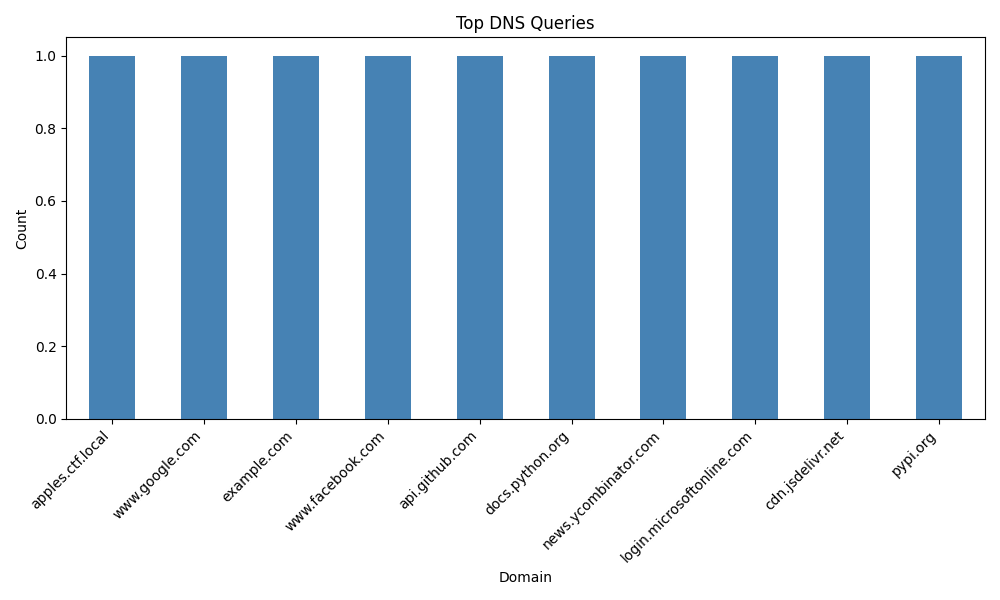

In [20]:
!python3.10 dns_analysis.py ../logs_college_dns_noise/dns.log
from IPython.display import Image, display
display(Image("dns_top_domains.png"))


In [21]:
print("# Zeek Version Discovery Demo using \"RG\"\n")

print("## 1. List all #define entries in zeek-version.h\n")
print("Command:")
print("  rg \"^#define\" /opt/zeek/include/zeek/zeek-version.h\n")

!rg "^#define" /opt/zeek/include/zeek/zeek-version.h

print("\n## 2. Search for specific Zeek version macros\n")
print("Command:")
print("  rg -B 1 -A 1 \"^#define ZEEK_VERSION\" -i /opt/zeek/include/zeek/zeek-version.h\n")

!rg -B 1 -A 1 "^#define ZEEK_VERSION" -i /opt/zeek/include/zeek/zeek-version.h


# Zeek Version Discovery Demo using "RG"

## 1. List all #define entries in zeek-version.h

Command:
  rg "^#define" /opt/zeek/include/zeek/zeek-version.h

6:#define VERSION "8.0.5"
11:#define ZEEK_VERSION_NUMBER 80005
14:#define ZEEK_VERSION_FUNCTION zeek_version_8_0_5_plugin_7

## 2. Search for specific Zeek version macros

Command:
  rg -B 1 -A 1 "^#define ZEEK_VERSION" -i /opt/zeek/include/zeek/zeek-version.h

10-// For example, 3.1.2 becomes 30102.
11:#define ZEEK_VERSION_NUMBER 80005
12-
13-/* A C function that has the Zeek version encoded into its name. */
14:#define ZEEK_VERSION_FUNCTION zeek_version_8_0_5_plugin_7
15-#ifdef __cplusplus


In [22]:
df['rcode_name'].value_counts()

rcode_name
-          12
NOERROR     1
Name: count, dtype: int64

In [23]:
import base64

data = "TFNDVEZ7RE5TX0VYRklMX0ZVTn0="
decoded = base64.b64decode(data).decode()
decoded


'LSCTF{DNS_EXFIL_FUN}'

In [24]:
def decode_answer(data):
    decoded = base64.b64decode(data).decode()
    return decoded

if __name__ == "__main__":
    data = "TFNDVEZ7RE5TX0VYRklMX0ZVTn0="
    print(decode_answer(data))

LSCTF{DNS_EXFIL_FUN}
